# Notebook 8 — Generate the missing paper figures

Paper references 10 figures; notebooks 06 and 07 already produced fig8, fig9, fig10; `corrected_output/` has fig3. The remaining four/five figures are generated here, all saved to the current directory as PNG.

Outputs:
- `fig1_histogram_large.png` — histogram of prime gaps at $N = 10^{11}$.
- `fig2_offset_vs_rho.png` — scatter of offset $y - x_C$ vs.~$\rho$, points coloured by $\omega(g)$.
- `fig5_aic_bars.png` — AIC bar chart for models $M_0$–$M_4$ on the extended dataset.
- `fig6_autocorrelation.png` — autocorrelation $\rho(k)$ for $k = 1, \ldots, 20$ on the gap sequence at $N = 10^8$, vs shuffled null.
- `fig7_sliding_window.png` — sliding-window $R^2_{\mathrm{CV}}$ as a function of the window centre $\rho_c$.

Requires: `ml_data/` cache from notebook 07 (for ML figs), and a numpy sieve run at $N = 10^8$ for autocorrelation.

In [1]:
import math, time
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import integrate, optimize
import matplotlib.pyplot as plt

DATA_DIR = Path.cwd() / 'ml_data'
C2_TWIN = 0.6601618158468695739278121100145557784326233602847334133194484233354

def hl_correct(g):
    if g <= 0 or g % 2: return 0.0
    n = g
    while n % 2 == 0: n //= 2
    corr, p = 1.0, 3
    while p*p <= n:
        if n % p == 0:
            corr *= (p-1)/(p-2)
            while n % p == 0: n //= p
        p += 2
    if n > 1: corr *= (n-1)/(n-2)
    return 2*C2_TWIN*corr

def omega(n):
    if n <= 1: return 0
    c, d = 0, 2
    while d*d <= n:
        if n % d == 0:
            c += 1
            while n % d == 0: n //= d
        d += 1
    if n > 1: c += 1
    return c

def li2(N):
    v, _ = integrate.quad(lambda t: 1.0/np.log(t)**2, 2.0, N, limit=200)
    return float(v)

print('using cache at', DATA_DIR)

using cache at /opt/apps/jupyter/work/ml_data


## Figure 1 — Histogram of gaps at $N = 10^{11}$

Bars coloured by divisibility by 6.

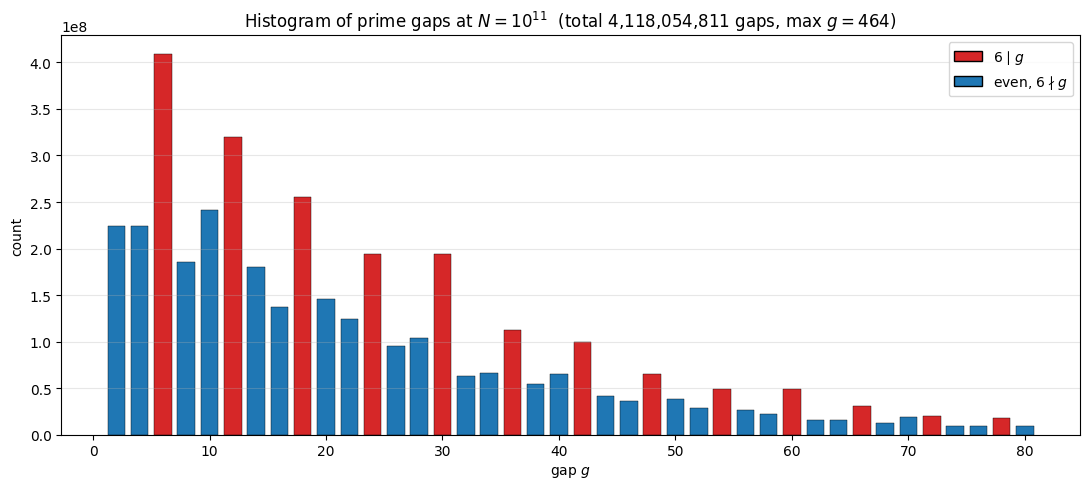

saved: fig1_histogram_large.png


In [2]:
N_big = int(1e11)
df = pd.read_csv(DATA_DIR / f'gaps_N{N_big}.csv')
df = df[df['gap'] >= 2]

def col(g):
    if g % 6 == 0: return '#d62728'     # red for 6|g
    if g % 2 == 0: return '#1f77b4'     # blue for even non-6
    return '#7f7f7f'

sub = df[df['gap'] <= 80]
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(sub['gap'], sub['count'], color=[col(g) for g in sub['gap']],
       edgecolor='black', linewidth=0.3, width=1.5)
ax.set_xlabel('gap $g$')
ax.set_ylabel('count')
ax.set_title(f'Histogram of prime gaps at $N = 10^{{11}}$'
             f'  (total {int(df["count"].sum()):,} gaps, max $g = {int(df["gap"].max())}$)')
ax.grid(alpha=0.3, axis='y')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#d62728', edgecolor='k', label='$6 \\mid g$'),
                    Patch(facecolor='#1f77b4', edgecolor='k', label='even, $6 \\nmid g$')],
          loc='upper right')
plt.tight_layout()
plt.savefig('fig1_histogram_large.png', dpi=130, bbox_inches='tight')
plt.show()
print('saved: fig1_histogram_large.png')

## Rebuild the corrected dataset (shared by figs 2, 5, 7)

In [3]:
RHO_MIN, RHO_MAX = 0.05, 1.10

histograms = {}
for f in sorted(DATA_DIR.glob('gaps_N*.csv')):
    N = int(f.stem.replace('gaps_N', ''))
    histograms[N] = pd.read_csv(f)
print(f'{len(histograms)} histograms cached')

rows = []
for N, df in histograms.items():
    lnN, lnlnN = math.log(N), math.log(math.log(N))
    li2_N = li2(N)
    for _, r in df.iterrows():
        g, emp = int(r['gap']), int(r['count'])
        if g < 2 or g > 100 or g % 2 or emp < 100: continue
        Cg = hl_correct(g)
        rho = g * Cg / lnN
        if not (RHO_MIN <= rho <= RHO_MAX): continue
        rows.append({
            'N': N, 'g': g,
            'log_empir': math.log(emp),
            'log_C_li':  math.log(Cg * li2_N),
            'rho': rho,
            'omega_g': omega(g),
            'sqrt_omega_g': math.sqrt(omega(g)),
            'lnlnN': lnlnN,
            'weight': min(1.0, emp / 1000.0),
        })
D = pd.DataFrame(rows)
print(f'dataset: {len(D)} points')

25 histograms cached
dataset: 140 points


## Figure 2 — Offset vs $\rho$ scatter, coloured by $\omega(g)$

M2 fit: alpha=0.4232, beta=1.5871


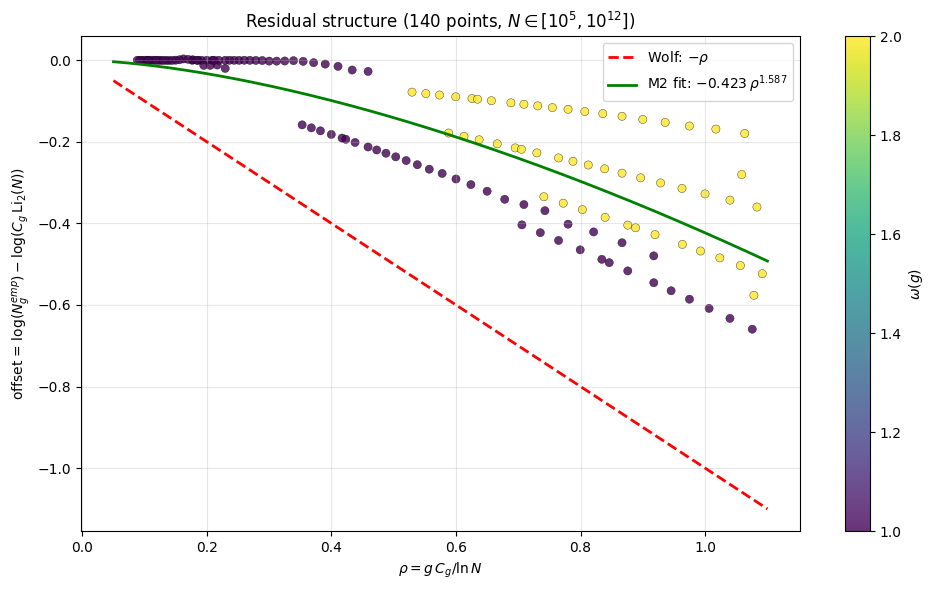

saved: fig2_offset_vs_rho.png


In [4]:
# Fit M2 for the reparametrised curve
def wloss(pred, y, w): return float(np.sum(w*(y-pred)**2))
y = D['log_empir'].values; lc = D['log_C_li'].values; rho_v = D['rho'].values; w = D['weight'].values
r2 = optimize.minimize(lambda p: wloss(lc - p[0]*rho_v**p[1], y, w),
                        [1.0, 1.0], bounds=[(0.1, 3.0), (0.3, 3.0)])
a2, b2 = r2.x
print(f'M2 fit: alpha={a2:.4f}, beta={b2:.4f}')

offset = D['log_empir'] - D['log_C_li']
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(D['rho'], offset, c=D['omega_g'], cmap='viridis',
                s=35, alpha=0.8, edgecolor='black', linewidth=0.3)
cbar = plt.colorbar(sc, ax=ax, label='$\\omega(g)$')

xs = np.linspace(RHO_MIN, RHO_MAX, 200)
ax.plot(xs, -xs, 'r--', linewidth=2, label='Wolf: $-\\rho$')
ax.plot(xs, -a2*xs**b2, 'g-', linewidth=2,
        label=f'M2 fit: $-{a2:.3f}\\,\\rho^{{{b2:.3f}}}$')

ax.set_xlabel('$\\rho = g\\,C_g / \\ln N$')
ax.set_ylabel('offset = $\\log(N_g^{emp}) - \\log(C_g\\,\\mathrm{Li}_2(N))$')
ax.set_title(f'Residual structure ({len(D)} points, $N \\in [10^5, 10^{{12}}]$)')
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_offset_vs_rho.png', dpi=130, bbox_inches='tight')
plt.show()
print('saved: fig2_offset_vs_rho.png')

## Figure 5 — AIC bar chart for the five models

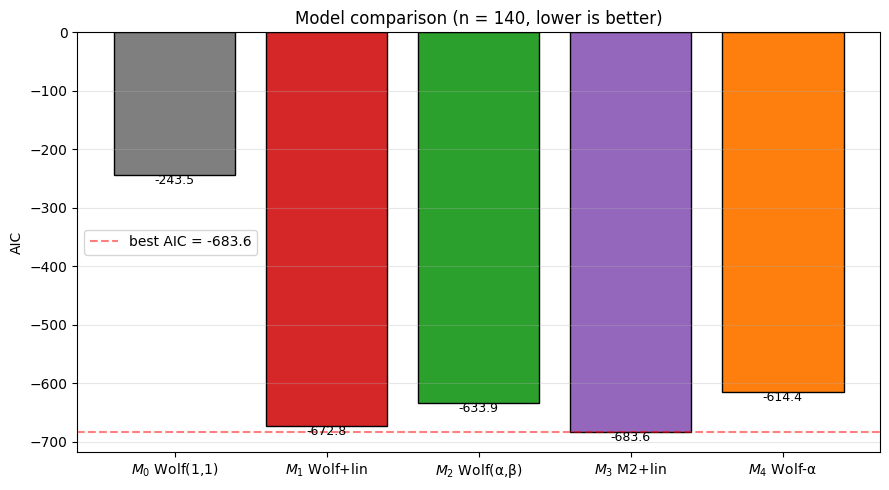

saved: fig5_aic_bars.png


In [5]:
def fit_wls(X, y, w):
    ws = np.sqrt(w); c, *_ = np.linalg.lstsq(X*ws[:,None], y*ws, rcond=None); return c
def aic(loss, k, n): return n*np.log(loss/n + 1e-12) + 2*k

X3 = np.column_stack([D['sqrt_omega_g'], D['lnlnN'], np.ones(len(D))])
n = len(D)
L0 = wloss(lc - rho_v, y, w)
c1 = fit_wls(X3, y - (lc - rho_v), w); L1 = wloss(lc - rho_v + X3@c1, y, w)
p2 = lc - a2*rho_v**b2; L2 = r2.fun
c3 = fit_wls(X3, y - p2, w); L3 = wloss(p2 + X3@c3, y, w)
r4 = optimize.minimize_scalar(lambda a: wloss(lc - a*rho_v, y, w),
                               bounds=(0.1, 3.0), method='bounded')
L4 = r4.fun

models = [('$M_0$ Wolf(1,1)', L0, 0),
          ('$M_1$ Wolf+lin',  L1, 3),
          ('$M_2$ Wolf(α,β)', L2, 2),
          ('$M_3$ M2+lin',    L3, 5),
          ('$M_4$ Wolf-α',    L4, 1)]
aics = [aic(L, k, n) for _, L, k in models]
names = [m[0] for m in models]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(names, aics, color=['#7f7f7f','#d62728','#2ca02c','#9467bd','#ff7f0e'],
               edgecolor='black')
ax.axhline(min(aics), color='red', ls='--', alpha=0.5, label=f'best AIC = {min(aics):.1f}')
for bar, val in zip(bars, aics):
    ax.text(bar.get_x() + bar.get_width()/2, val - 15, f'{val:.1f}',
            ha='center', fontsize=9)
ax.set_ylabel('AIC'); ax.set_title(f'Model comparison (n = {n}, lower is better)')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig5_aic_bars.png', dpi=130, bbox_inches='tight')
plt.show()
print('saved: fig5_aic_bars.png')

## Figure 6 — Autocorrelation $\rho(k)$

We rebuild primes up to $N = 10^8$ using a numpy sieve and compute autocorrelation of consecutive gaps, compared against a shuffled null (20 permutations).

sieve+diff in 0.6s, 5,761,453 gaps


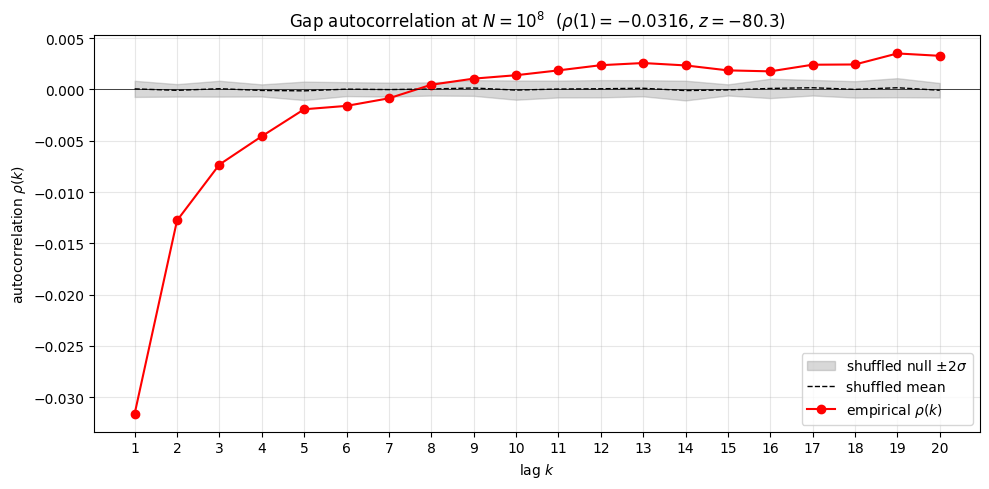

saved: fig6_autocorrelation.png


In [6]:
def sieve_primes(n):
    is_prime = np.ones(n + 1, dtype=bool)
    is_prime[:2] = False; is_prime[4::2] = False
    for i in range(3, int(math.isqrt(n)) + 1, 2):
        if is_prime[i]:
            is_prime[i*i::2*i] = False
    return np.flatnonzero(is_prime).astype(np.int64)

N_SEQ = 10**8
t0 = time.perf_counter()
primes = sieve_primes(N_SEQ)
gaps = np.diff(primes).astype(np.float64)
gaps = gaps[gaps >= 2]          # drop the gap=1 artefact
gaps -= gaps.mean()
var = (gaps*gaps).mean()
print(f'sieve+diff in {time.perf_counter()-t0:.1f}s, {len(gaps):,} gaps')

MAX_LAG = 20
def acorr(x, max_lag):
    out = np.empty(max_lag + 1); out[0] = 1.0
    for k in range(1, max_lag + 1):
        out[k] = (x[:-k] * x[k:]).mean() / var
    return out

rho_emp = acorr(gaps, MAX_LAG)
rng = np.random.default_rng(42)
n_shuf = 20
null = np.empty((n_shuf, MAX_LAG + 1))
gs = gaps.copy()
for i in range(n_shuf):
    rng.shuffle(gs)
    null[i] = acorr(gs, MAX_LAG)
mu, sig = null.mean(0), null.std(0, ddof=1)

lags = np.arange(MAX_LAG + 1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(lags[1:], (mu - 2*sig)[1:], (mu + 2*sig)[1:],
                color='gray', alpha=0.3, label='shuffled null $\\pm 2\\sigma$')
ax.plot(lags[1:], mu[1:], 'k--', linewidth=1, label='shuffled mean')
ax.plot(lags[1:], rho_emp[1:], 'ro-', linewidth=1.5, markersize=6,
        label='empirical $\\rho(k)$')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('lag $k$'); ax.set_ylabel('autocorrelation $\\rho(k)$')
ax.set_title(f'Gap autocorrelation at $N = 10^8$  '
             f'($\\rho(1) = {rho_emp[1]:+.4f}$, $z = {rho_emp[1]/sig[1]:.1f}$)')
ax.legend(); ax.grid(alpha=0.3)
ax.set_xticks(lags[1:])
plt.tight_layout()
plt.savefig('fig6_autocorrelation.png', dpi=130, bbox_inches='tight')
plt.show()
print('saved: fig6_autocorrelation.png')

## Figure 7 — Sliding-window $R^2_{\mathrm{CV}}$ vs.~$\rho_c$

Window half-width $\Delta\rho = 0.15$. For each window centre $\rho_c$, take points with $\rho \in [\rho_c - \Delta\rho, \rho_c + \Delta\rho]$, run hold-out-one-$N$ CV, report median $R^2$.

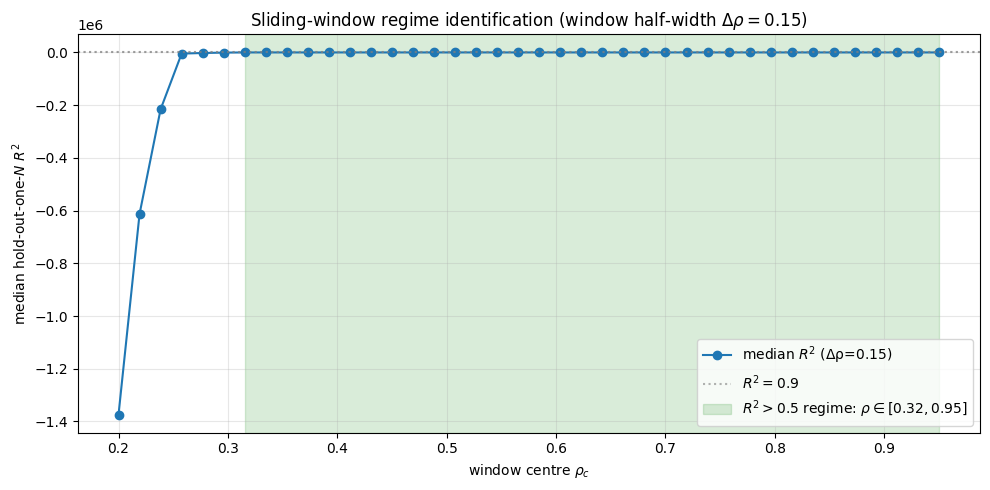

saved: fig7_sliding_window.png

Sliding-window diagnostic:
 rho_c  n_pts           R2
 0.200     44 -1373990.025
 0.219     47  -612549.750
 0.238     48  -215736.468
 0.258     45    -4362.700
 0.277     43    -2118.018
 0.296     41     -645.136
 0.315     40        0.947
 0.335     37        0.967
 0.354     35        0.984
 0.373     31        0.992
 0.392     30        0.991
 0.412     29        0.996
 0.431     29        0.999
 0.450     30        0.998
 0.469     30        0.995
 0.488     33        0.994
 0.508     32        0.994
 0.527     31        0.995
 0.546     32        0.991
 0.565     34        0.988
 0.585     33        0.987
 0.604     35        0.984
 0.623     36        0.976
 0.642     38        0.977
 0.662     40        0.975
 0.681     40        0.976
 0.700     44        0.977
 0.719     45        0.974
 0.738     45        0.977
 0.758     45        0.969
 0.777     45        0.954
 0.796     46        0.940
 0.815     46        0.934
 0.835     46        0.

In [7]:
def r2_cv_subset(sub):
    Ns = sub['N'].unique()
    if len(Ns) < 3: return np.nan
    r2s = []
    for N in Ns:
        tr = sub[sub['N'] != N]; te = sub[sub['N'] == N]
        if len(tr) < 6 or len(te) < 2: continue
        w_ = tr['weight'].values
        X = np.column_stack([tr['sqrt_omega_g'], tr['lnlnN'], np.ones(len(tr))])
        c = fit_wls(X, tr['log_empir'].values - (tr['log_C_li'].values - tr['rho'].values), w_)
        Xt = np.column_stack([te['sqrt_omega_g'], te['lnlnN'], np.ones(len(te))])
        pred = te['log_C_li'].values - te['rho'].values + Xt @ c
        y_ = te['log_empir'].values; wt = te['weight'].values
        ss_r = (wt*(y_-pred)**2).sum(); ss_t = (wt*(y_-y_.mean())**2).sum()
        if ss_t > 1e-12:
            r2s.append(1 - ss_r/ss_t)
    return float(np.median(r2s)) if r2s else np.nan

DRHO = 0.15
centres = np.linspace(RHO_MIN + DRHO, RHO_MAX - DRHO, 40)
scores = []
for rc in centres:
    mask = (D['rho'] >= rc - DRHO) & (D['rho'] <= rc + DRHO)
    scores.append((rc, int(mask.sum()), r2_cv_subset(D[mask])))

sw = pd.DataFrame(scores, columns=['rho_c', 'n_pts', 'R2'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sw['rho_c'], sw['R2'], 'o-', color='tab:blue', label=f'median $R^2$ (Δρ={DRHO})')
ax.axhline(0.9, color='gray', ls=':', alpha=0.6, label='$R^2 = 0.9$')
ax.axhline(0.5, color='gray', ls=':', alpha=0.4)
ax.axhspan(0.05, 1.10, alpha=0)   # keep axis comfortable
good = sw[sw['R2'] > 0.5]
if len(good):
    lo, hi = good['rho_c'].min(), good['rho_c'].max()
    ax.axvspan(lo, hi, alpha=0.15, color='green',
               label=f'$R^2 > 0.5$ regime: $\\rho \\in [{lo:.2f}, {hi:.2f}]$')
ax.set_xlabel('window centre $\\rho_c$')
ax.set_ylabel('median hold-out-one-$N$ $R^2$')
ax.set_title(f'Sliding-window regime identification (window half-width $\\Delta\\rho = {DRHO}$)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig7_sliding_window.png', dpi=130, bbox_inches='tight')
plt.show()
print('saved: fig7_sliding_window.png')
print('\nSliding-window diagnostic:')
print(sw.round(3).to_string(index=False))

## Done

All five figures (`fig1_histogram_large`, `fig2_offset_vs_rho`, `fig5_aic_bars`, `fig6_autocorrelation`, `fig7_sliding_window`) are saved to the current directory. Copy them to `/home/krse/development/papers/figures/` alongside the already-present figs 3, 4/10, 8, 9.

Naming convention note: the paper references Figure~4 as the $R^2_{\mathrm{CV}}$ trajectory; that figure is `fig10_r2_trajectory.png` produced by notebook~07. Either rename to `fig4_r2_trajectory.png` for clarity, or edit the paper to say `[Figure 4 = fig10\_r2\_trajectory.png]` in the placeholder.